In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
# load local CSVs from the project root
dfTrain = pd.read_csv('train.csv')
dfTest = pd.read_csv('test.csv')

In [52]:
dfTrain.shape

(594194, 21)

In [53]:
dfTest.shape

(254655, 20)

In [54]:
dfTrain.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [55]:
dfTrain.tail()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


In [56]:
dfTrain.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  PaperlessBilling  594194 non-nu

In [57]:
dfTrain.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


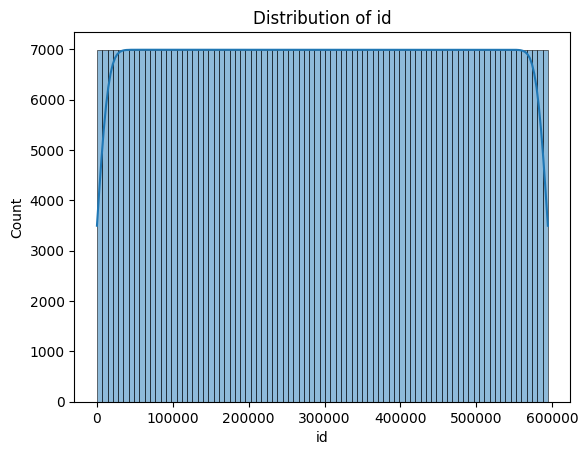

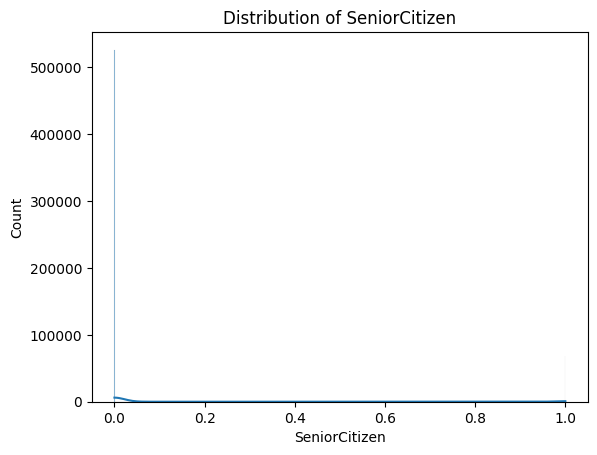

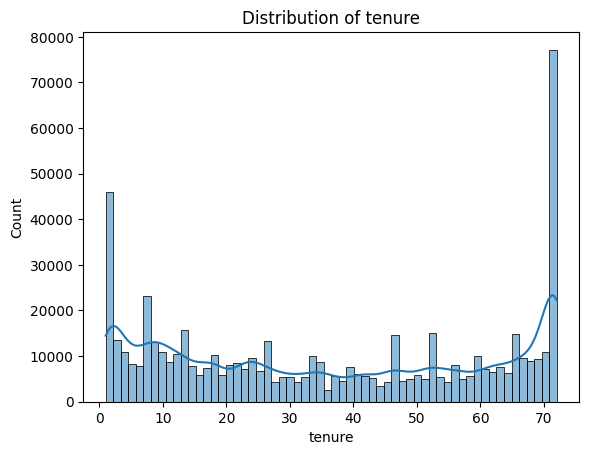

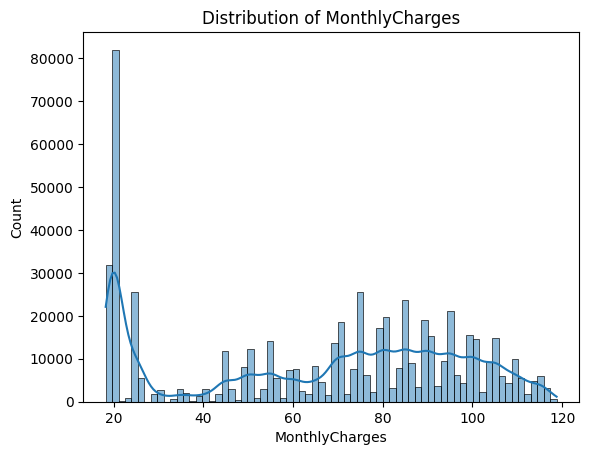

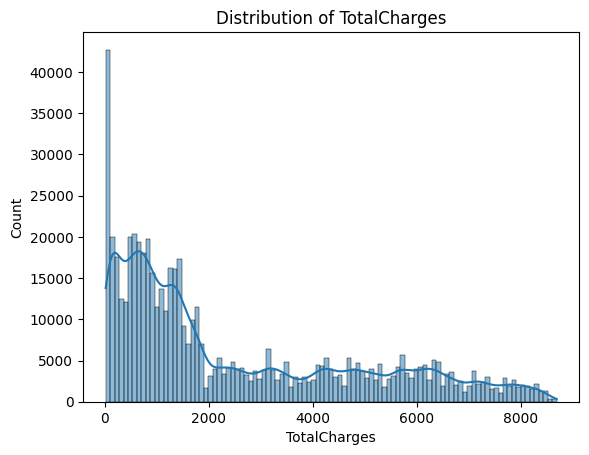

/tmp/ipykernel_8444/1920687423.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = dfTrain.select_dtypes(include=['object','category']).columns


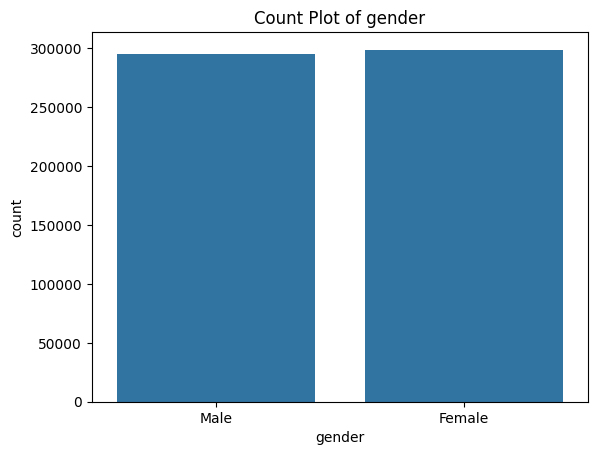

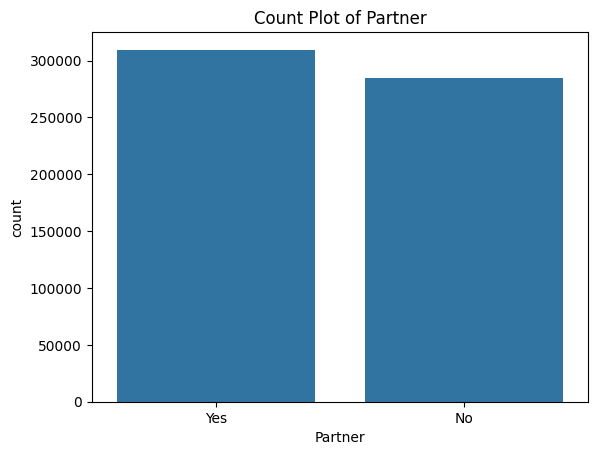

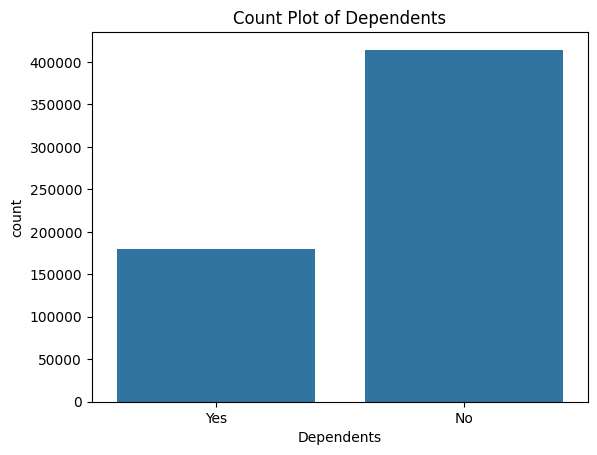

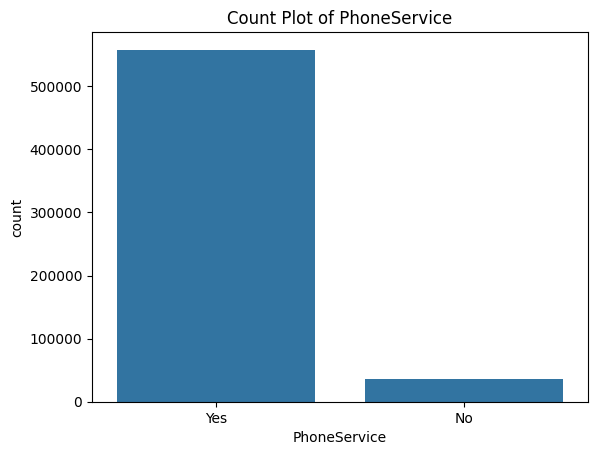

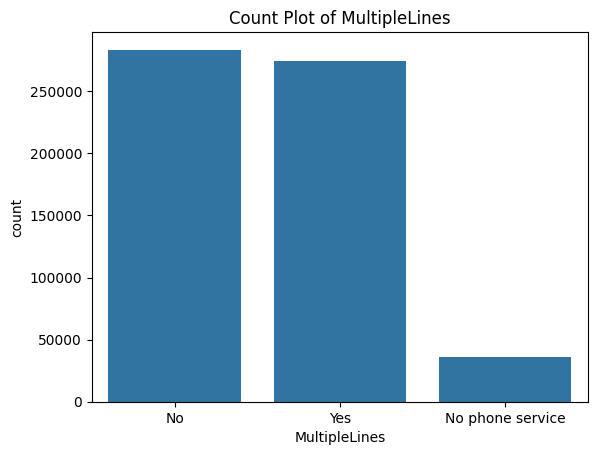

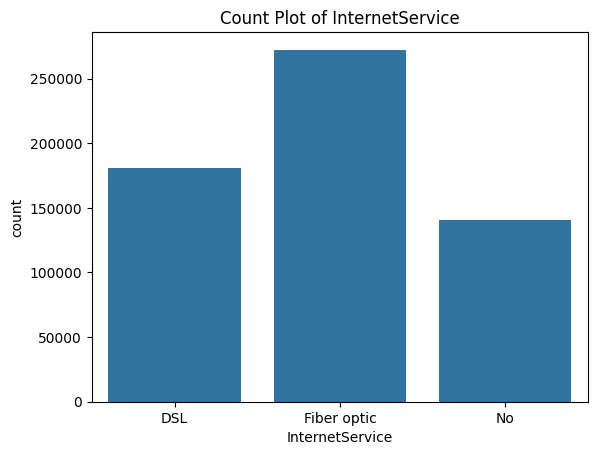

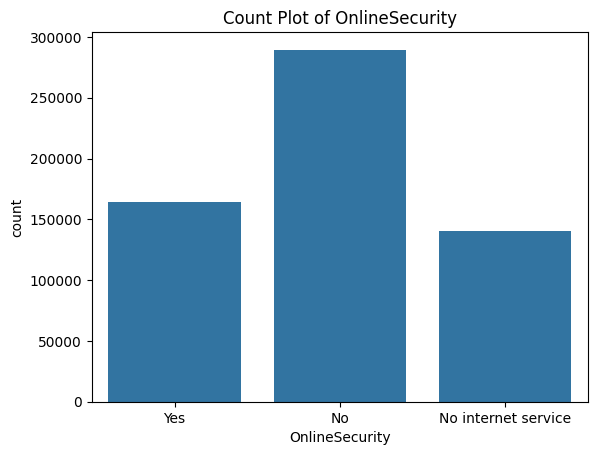

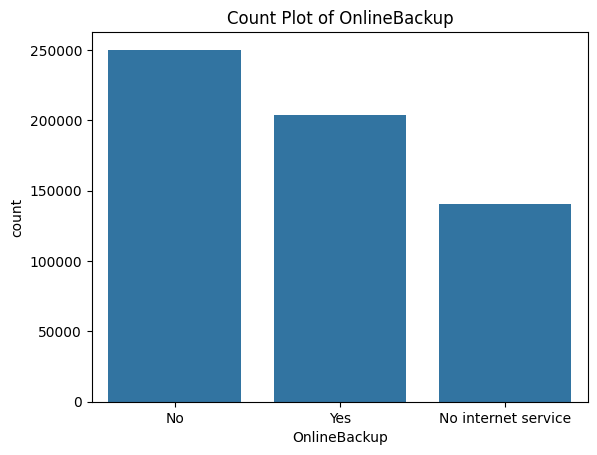

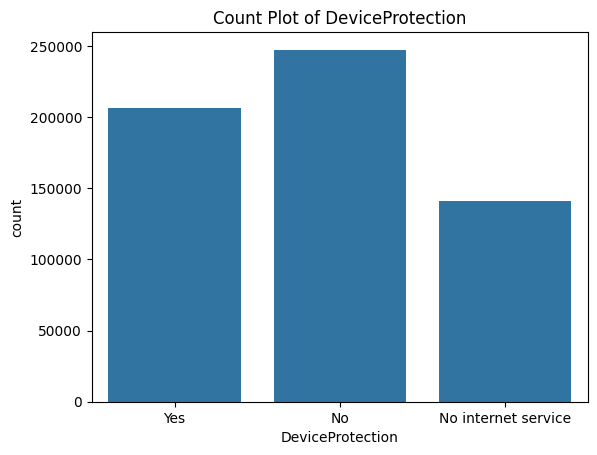

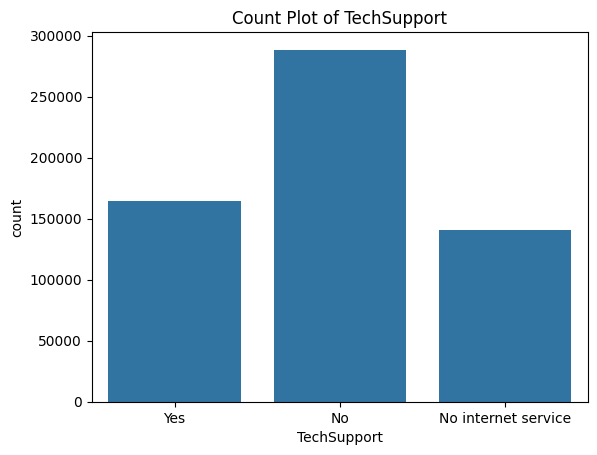

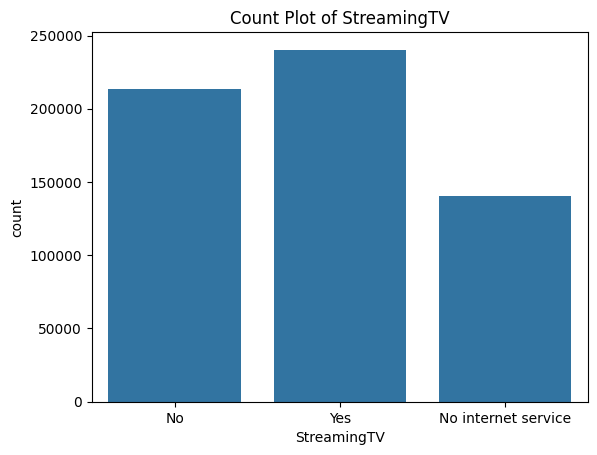

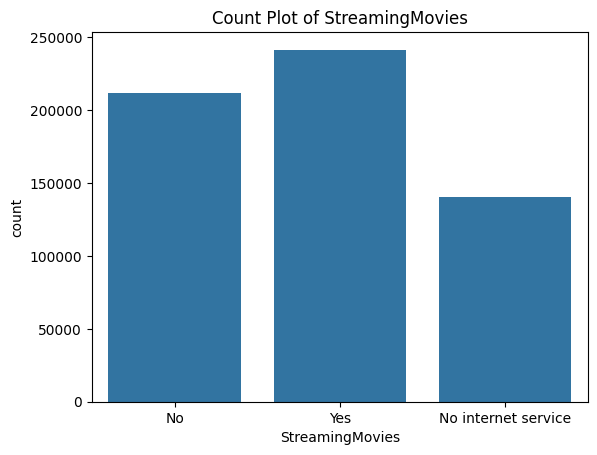

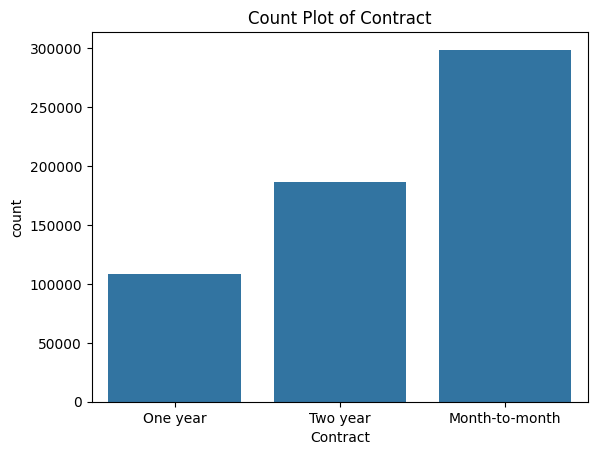

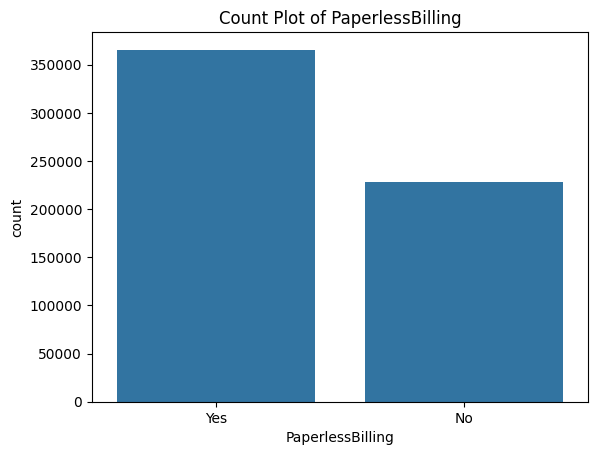

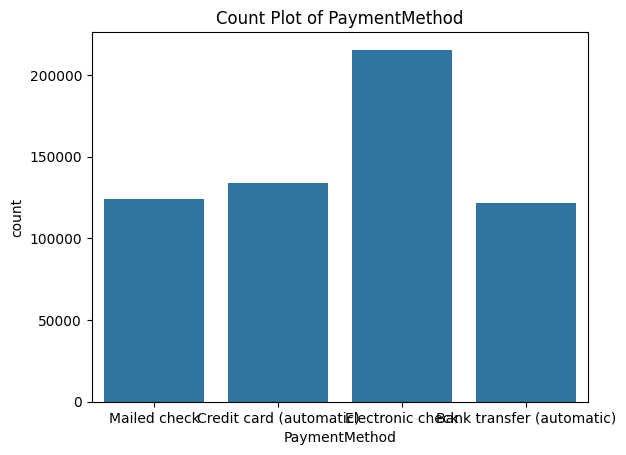

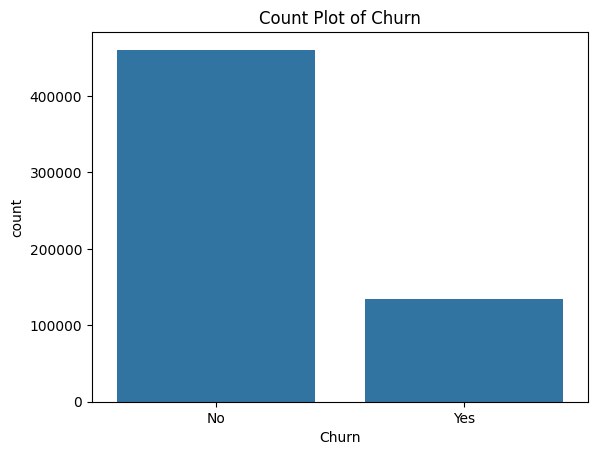

In [58]:
#plotting graphs for each feature
import seaborn as sns


# Numerical features
num_cols = dfTrain.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(dfTrain[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()


# Categorical features
cat_cols = dfTrain.select_dtypes(include=['object','category']).columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=dfTrain[col])
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.show()

In [59]:
#converting the data type of the SineorCotizens to object type
dfTrain['SeniorCitizen'] = dfTrain['SeniorCitizen'].astype('object')
dfTest['SeniorCitizen'] = dfTest['SeniorCitizen'].astype('object')

In [60]:
#Looking what sort of elements are in categorical features
for col in dfTrain.columns:
    if dfTrain[col].dtype != 'int64' and dfTrain[col].dtype != 'float64':
        print(f'{col} : {dfTrain[col].unique()}')


gender : <StringArray>
['Male', 'Female']
Length: 2, dtype: str
SeniorCitizen : [0 1]
Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
PhoneService : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
MultipleLines : <StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
TechSupport : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
StreamingTV : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract : <StringArra

In [61]:
#replace Yes, No and other catergories with numerical values
binCat= ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling','Churn']
mapping = {'Yes' : 1, 'No' : 0}

for col in binCat:
    if col != 'Churn' :
        dfTest[col] = dfTest[col].map(mapping)

    dfTrain[col] = dfTrain[col].map(mapping)

In [62]:
#one hot encoding
dfTrain = pd.get_dummies(dfTrain)
dfTest = pd.get_dummies(dfTest)

In [63]:
dfTrain.info()

<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 44 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   id                                       594194 non-null  int64  
 1   Partner                                  594194 non-null  int64  
 2   Dependents                               594194 non-null  int64  
 3   tenure                                   594194 non-null  int64  
 4   PhoneService                             594194 non-null  int64  
 5   PaperlessBilling                         594194 non-null  int64  
 6   MonthlyCharges                           594194 non-null  float64
 7   TotalCharges                             594194 non-null  float64
 8   Churn                                    594194 non-null  int64  
 9   gender_Female                            594194 non-null  bool   
 10  gender_Male                              59

In [64]:
#feature engineering using gplearn

from gplearn.genetic import SymbolicTransformer



# Initialize SymbolicTransformer with custom metric
transformer_mi = SymbolicTransformer(
    generations=10,
    population_size=100,
    hall_of_fame=5,
    n_components=3,
    function_set=('add','sub','mul','div','sqrt','log','abs'),
    metric='spearman',  
    verbose=1,
    random_state=42
)

transformer_mi.fit( dfTrain.drop(columns=['Churn']), dfTrain['Churn'])

# Transform train data
X_train_new_features = transformer_mi.transform(dfTrain.drop(columns=['Churn']))

# Transform test data
X_test_new_features = transformer_mi.transform(dfTest)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    10.98         0.171491        3         0.476255              N/A      3.16m
   1     4.58         0.365463        5         0.539364              N/A      1.91m
   2     2.82         0.448588        5         0.539364              N/A      1.41m
   3     5.20         0.486687        9         0.539364              N/A      1.43m
   4     5.02         0.505577        5         0.539364              N/A      1.16m
   5     4.91         0.509749        5         0.539364              N/A     53.12s
   6     5.14         0.504534        5         0.539364              N/A     41.22s
   7     4.89         0.497731        7         0.539364              N/A     29.36s
   8     4.86         0.494955        7         0.539364              N/A  

In [65]:
#add new values to the original dataframes
new_feature_names = [f'gp_feature_{i}' for i in range(X_train_new_features.shape[1])]

# Create the x and y  for the training data
xTrain = dfTrain.drop(columns=['Churn'])
yTrain = dfTrain['Churn']

dfTrain = pd.concat([
    dfTrain, 
    pd.DataFrame(X_train_new_features, columns=new_feature_names, index=dfTrain.index)
], axis=1)

dfTest = pd.concat([
    dfTest,
    pd.DataFrame(X_test_new_features, columns=new_feature_names, index=dfTest.index)
], axis=1)

In [66]:
#Select the top 20 features using mutual information
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(mutual_info_classif, k=20)
X_new = selector.fit_transform(X, y)



In [67]:
# Observe the selected features
selected_features = X.columns[selector.get_support()]
print(selected_features)


Index(['Partner', 'tenure', 'PhoneService', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_0',
       'InternetService_Fiber optic', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'DeviceProtection_No',
       'TechSupport_No', 'Contract_Month-to-month', 'Contract_Two year',
       'PaymentMethod_Electronic check', 'gp_feature_0', 'gp_feature_1',
       'gp_feature_2'],
      dtype='str')


In [68]:
# Create the train and test data sets accordingly

yTrain = dfTrain['Churn']
xTrain = dfTrain[list(selected_features) + [
    'PaymentMethod_Bank transfer (automatic)',
    'PaymentMethod_Credit card (automatic)',
    'DeviceProtection_Yes',
    'TechSupport_Yes'
]]

In [71]:
xTest = xTrain[xTrain.columns]

In [72]:
print(xTrain.columns)
print(xTest.columns)

Index(['Partner', 'tenure', 'PhoneService', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_0',
       'InternetService_Fiber optic', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'DeviceProtection_No',
       'TechSupport_No', 'Contract_Month-to-month', 'Contract_Two year',
       'PaymentMethod_Electronic check', 'gp_feature_0', 'gp_feature_1',
       'gp_feature_2', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)', 'DeviceProtection_Yes',
       'TechSupport_Yes'],
      dtype='str')
Index(['Partner', 'tenure', 'PhoneService', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'SeniorCitizen_0',
       'InternetService_Fiber optic', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'DeviceProtection_No',
       'TechSupport_No', 'Contract_Month-to-

In [76]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score

# Calculate the scale_pos_weight for XGBoost
neg = (yTrain == 0).sum()
pos = (yTrain == 1).sum()
scale_pos_weight = neg / pos


model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_validate(
    model,
    xTrain,
    yTrain,
    cv=cv,
    scoring=scoring
)

/home/yohan-jayasinghe/Documents/CSE Sem 4/Intro to ML/Kaggle Competition/Predicting_Customer_Churn_KaggleComp/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [18:07:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/yohan-jayasinghe/Documents/CSE Sem 4/Intro to ML/Kaggle Competition/Predicting_Customer_Churn_KaggleComp/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [18:07:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/yohan-jayasinghe/Documents/CSE Sem 4/Intro to ML/Kaggle Competition/Predicting_Customer_Churn_KaggleComp/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [18:07:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

In [77]:
print("Cross-validation scores:")
print(f"Accuracy: {scores['test_accuracy'].mean():.4f})")
print(f"F1 Score: {scores['test_f1'].mean():.4f})")
print(f"ROC AUC: {scores['test_roc_auc'].mean():.4f})")

Cross-validation scores:
Accuracy: 0.8192)
F1 Score: 0.6852)
ROC AUC: 0.9152)
